# VDS Xarray Backend - Complete Example

This notebook demonstrates the key features and capabilities of the VDS Xarray Backend.

## What You'll Learn

1. **Loading VDS files** with xarray
2. **Exploring dataset structure** and metadata
3. **Coordinate-aware data selection** 
4. **Visualization** of seismic data
5. **Performance benefits** of chunked processing
6. **Data analysis workflows**

## Prerequisites

```bash
pip install vdsxarray matplotlib scipy
```

In [1]:
# Import required libraries
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## 1. Loading VDS Data

The VDS Xarray Backend makes loading VDS files as simple as any other xarray-supported format:

In [12]:
# Load VDS file - replace with your file path
vds_path = "/glb/hou/ua.sepco/data.nobackup/xdigi/screenplay/mars_ursa/seismics/vds/f1c.b2_578764_SHL22MUOBS_URSACGVRTLSM0RMO_4D15N.vds"

# For demonstration, we'll use a placeholder
# In practice, replace with your actual VDS file
try:
    ds = xr.open_dataset(vds_path, engine="vds")
    print("✅ VDS file loaded successfully!")
except FileNotFoundError:
    print("⚠️  VDS file not found. Using synthetic data for demonstration.")
    # Create synthetic data for demonstration
    ds = create_synthetic_seismic_data()
except Exception as e:
    print(f"❌ Error loading VDS file: {e}")
    print("Creating synthetic data for demonstration...")
    ds = create_synthetic_seismic_data()

✅ VDS file loaded successfully!


In [4]:
def create_synthetic_seismic_data():
    """Create synthetic seismic data for demonstration"""
    
    # Define dimensions
    inline_coords = np.arange(1000, 1201)  # 201 inlines
    crossline_coords = np.arange(2000, 2101)  # 101 crosslines  
    sample_coords = np.arange(0, 1000, 2)  # 500 samples, 2ms spacing
    
    # Create synthetic seismic data
    np.random.seed(42)  # Reproducible results
    
    # Generate realistic seismic-like data
    n_inline, n_crossline, n_sample = len(inline_coords), len(crossline_coords), len(sample_coords)
    
    # Base reflectivity with some geological structure
    reflectivity = np.random.randn(n_inline, n_crossline, n_sample) * 0.1
    
    # Add some coherent events (horizons)
    for horizon_time in [100, 200, 350, 500, 700]:
        horizon_idx = int(horizon_time / 2)  # Convert to sample index
        if horizon_idx < n_sample:
            # Add structural dip
            for i, inline in enumerate(inline_coords):
                for j, crossline in enumerate(crossline_coords):
                    dip_offset = int((i * 0.1 + j * 0.05))  # Structural dip
                    sample_idx = min(horizon_idx + dip_offset, n_sample - 1)
                    reflectivity[i, j, sample_idx] += np.random.normal(0.5, 0.1)
    
    # Apply wavelet convolution for realistic appearance
    # Simple Ricker wavelet
    def ricker_wavelet(f, dt, length):
        t = np.arange(-length//2, length//2) * dt
        return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)
    
    wavelet = ricker_wavelet(25, 0.002, 64)  # 25 Hz Ricker wavelet
    
    # Convolve each trace with wavelet
    amplitude = np.zeros_like(reflectivity)
    for i in range(n_inline):
        for j in range(n_crossline):
            amplitude[i, j, :] = np.convolve(reflectivity[i, j, :], wavelet, mode='same')
    
    # Add noise
    amplitude += np.random.randn(*amplitude.shape) * 0.05
    
    # Create xarray Dataset
    ds = xr.Dataset(
        {
            'Amplitude': (['inline', 'crossline', 'sample'], amplitude.astype(np.float32))
        },
        coords={
            'inline': inline_coords,
            'crossline': crossline_coords, 
            'sample': sample_coords.astype(np.float32)
        },
        attrs={
            'title': 'Synthetic Seismic Data for VDS Xarray Demo',
            'source': 'Generated for demonstration purposes',
            'created_with': 'vdsxarray example notebook',
            'sample_rate': '2.0 ms',
            'coordinate_system': 'Local grid'
        }
    )
    
    # Add coordinate attributes
    ds.inline.attrs = {'long_name': 'Inline Number', 'units': 'dimensionless'}
    ds.crossline.attrs = {'long_name': 'Crossline Number', 'units': 'dimensionless'}
    ds.sample.attrs = {'long_name': 'Time', 'units': 'milliseconds'}
    ds.Amplitude.attrs = {'long_name': 'Seismic Amplitude', 'units': 'dimensionless'}
    
    # Chunk the data (simulating VDS chunking)
    ds = ds.chunk({'inline': 50, 'crossline': 50, 'sample': 100})
    
    return ds

## 2. Exploring Dataset Structure

Let's examine what we loaded and understand the dataset structure:

In [13]:
# Display dataset overview
print("📊 Dataset Overview:")
print(ds)
print("\n" + "="*60)

# Dataset dimensions and size
print(f"\n📏 Dataset Dimensions:")
for dim, size in ds.dims.items():
    print(f"  {dim}: {size}")

print(f"\n💾 Dataset Size:")
print(f"  Total size: {ds.nbytes / 1e6:.1f} MB")
print(f"  In memory: {ds.nbytes / 1e6 if not hasattr(ds.Amplitude.data, 'chunks') else 'Lazy loaded'}")

📊 Dataset Overview:
<xarray.Dataset> Size: 21GB
Dimensions:    (inline: 1401, crossline: 1351, sample: 2741)
Coordinates:
  * inline     (inline) int16 3kB 1300 1301 1302 1303 ... 2697 2698 2699 2700
  * crossline  (crossline) int16 3kB 2500 2502 2504 2506 ... 5194 5196 5198 5200
  * sample     (sample) float32 11kB 0.0 3.048 6.096 ... 8.348e+03 8.352e+03
Data variables:
    Amplitude  (inline, crossline, sample) float32 21GB ...
Attributes:
    title:         VDS Seismic Data: Amplitude
    source:        /glb/hou/ua.sepco/data.nobackup/xdigi/screenplay/mars_ursa...
    created_with:  vdsxarray


📏 Dataset Dimensions:
  inline: 1401
  crossline: 1351
  sample: 2741

💾 Dataset Size:
  Total size: 20752.1 MB
  In memory: Lazy loaded


In [14]:
# Examine coordinate ranges
print("🗺️  Coordinate Ranges:")
print(f"  Inline: {ds.inline.min().values} to {ds.inline.max().values} (step: {ds.inline.diff('inline').values[0]})")
print(f"  Crossline: {ds.crossline.min().values} to {ds.crossline.max().values} (step: {ds.crossline.diff('crossline').values[0]})")
print(f"  Sample: {ds.sample.min().values:.1f} to {ds.sample.max().values:.1f} ms (step: {ds.sample.diff('sample').values[0]:.1f} ms)")

# Check if data is chunked
print(f"\n🧩 Chunking Information:")
if hasattr(ds.Amplitude.data, 'chunks'):
    print(f"  Data is chunked: Yes")
    print(f"  Chunk sizes: {ds.Amplitude.chunksizes}")
    print(f"  Number of chunks: {ds.Amplitude.data.npartitions}")
else:
    print(f"  Data is chunked: No (all in memory)")

🗺️  Coordinate Ranges:
  Inline: 1300 to 2700 (step: 1)
  Crossline: 2500 to 5200 (step: 2)
  Sample: 0.0 to 8351.5 ms (step: 3.0 ms)

🧩 Chunking Information:
  Data is chunked: Yes
  Chunk sizes: Frozen({})
  Number of chunks: 2662


In [15]:
# Display metadata
print("📋 Dataset Metadata:")
for key, value in ds.attrs.items():
    print(f"  {key}: {value}")

print("\n📋 Variable Metadata:")
for var_name, var in ds.data_vars.items():
    print(f"  {var_name}:")
    for attr_key, attr_val in var.attrs.items():
        print(f"    {attr_key}: {attr_val}")

📋 Dataset Metadata:
  title: VDS Seismic Data: Amplitude
  source: /glb/hou/ua.sepco/data.nobackup/xdigi/screenplay/mars_ursa/seismics/vds/f1c.b2_578764_SHL22MUOBS_URSACGVRTLSM0RMO_4D15N.vds
  created_with: vdsxarray

📋 Variable Metadata:
  Amplitude:
    source_file: /glb/hou/ua.sepco/data.nobackup/xdigi/screenplay/mars_ursa/seismics/vds/f1c.b2_578764_SHL22MUOBS_URSACGVRTLSM0RMO_4D15N.vds
    shape: (1401, 1351, 2741)
    coordinate_ranges: {'inline': [np.int16(1300), np.int16(2700)], 'crossline': [np.int16(2500), np.int16(5200)], 'sample': [np.float32(0.0), np.float32(8351.5205)]}


## 3. Coordinate-Aware Data Selection

One of the key benefits of xarray is coordinate-aware selection - you can select data using actual coordinate values rather than array indices:

In [ ]:
# Select by coordinate values (not array indices!)
print("🎯 Coordinate-Aware Selection Examples:")

middle_location = ds.inline

# Select a single inline section
inline_section = ds.sel(inline=1100)
print(f"  Single inline (1100): shape {inline_section.Amplitude.shape}")

# Select a single crossline section  
crossline_section = ds.sel(crossline=2050)
print(f"  Single crossline (2050): shape {crossline_section.Amplitude.shape}")

# Select a time slice
time_slice = ds.sel(sample=200, method='nearest')  # Nearest to 200ms
print(f"  Time slice (~200ms): shape {time_slice.Amplitude.shape}")

# Select a 3D volume subset
volume_subset = ds.sel(
    inline=slice(1050, 1150),    # 100 inlines
    crossline=slice(2025, 2075), # 50 crosslines
    sample=slice(100, 400)       # 100-400ms
)
print(f"  Volume subset: shape {volume_subset.Amplitude.shape}")
print(f"  Subset size: {volume_subset.nbytes / 1e6:.1f} MB")

🎯 Coordinate-Aware Selection Examples:


KeyError: "not all values found in index 'inline'. Try setting the `method` keyword argument (example: method='nearest')."

In [10]:
# Demonstrate the difference between .sel() and .isel()
print("🔍 Coordinate vs Index Selection:")

# Using coordinates (.sel) - RECOMMENDED
coord_selection = ds.sel(inline=1100, crossline=2050)
print(f"  Using coordinates: inline=1100, crossline=2050")
print(f"  Result: {coord_selection.Amplitude.values.shape} trace")

# Using indices (.isel) - less intuitive
index_selection = ds.isel(inline=100, crossline=50)  
actual_inline = ds.inline.values[100]
actual_crossline = ds.crossline.values[50]
print(f"  Using indices: inline[100]={actual_inline}, crossline[50]={actual_crossline}")
print(f"  Result: {index_selection.Amplitude.values.shape} trace")

print("\n💡 Tip: Use .sel() with coordinate values for clarity and robustness!")

🔍 Coordinate vs Index Selection:
  Using coordinates: inline=1100, crossline=2050
  Result: (500,) trace
  Using indices: inline[100]=1100, crossline[50]=2050
  Result: (500,) trace

💡 Tip: Use .sel() with coordinate values for clarity and robustness!


## 4. Data Visualization

Xarray makes visualization straightforward with built-in plotting capabilities and seamless matplotlib integration:

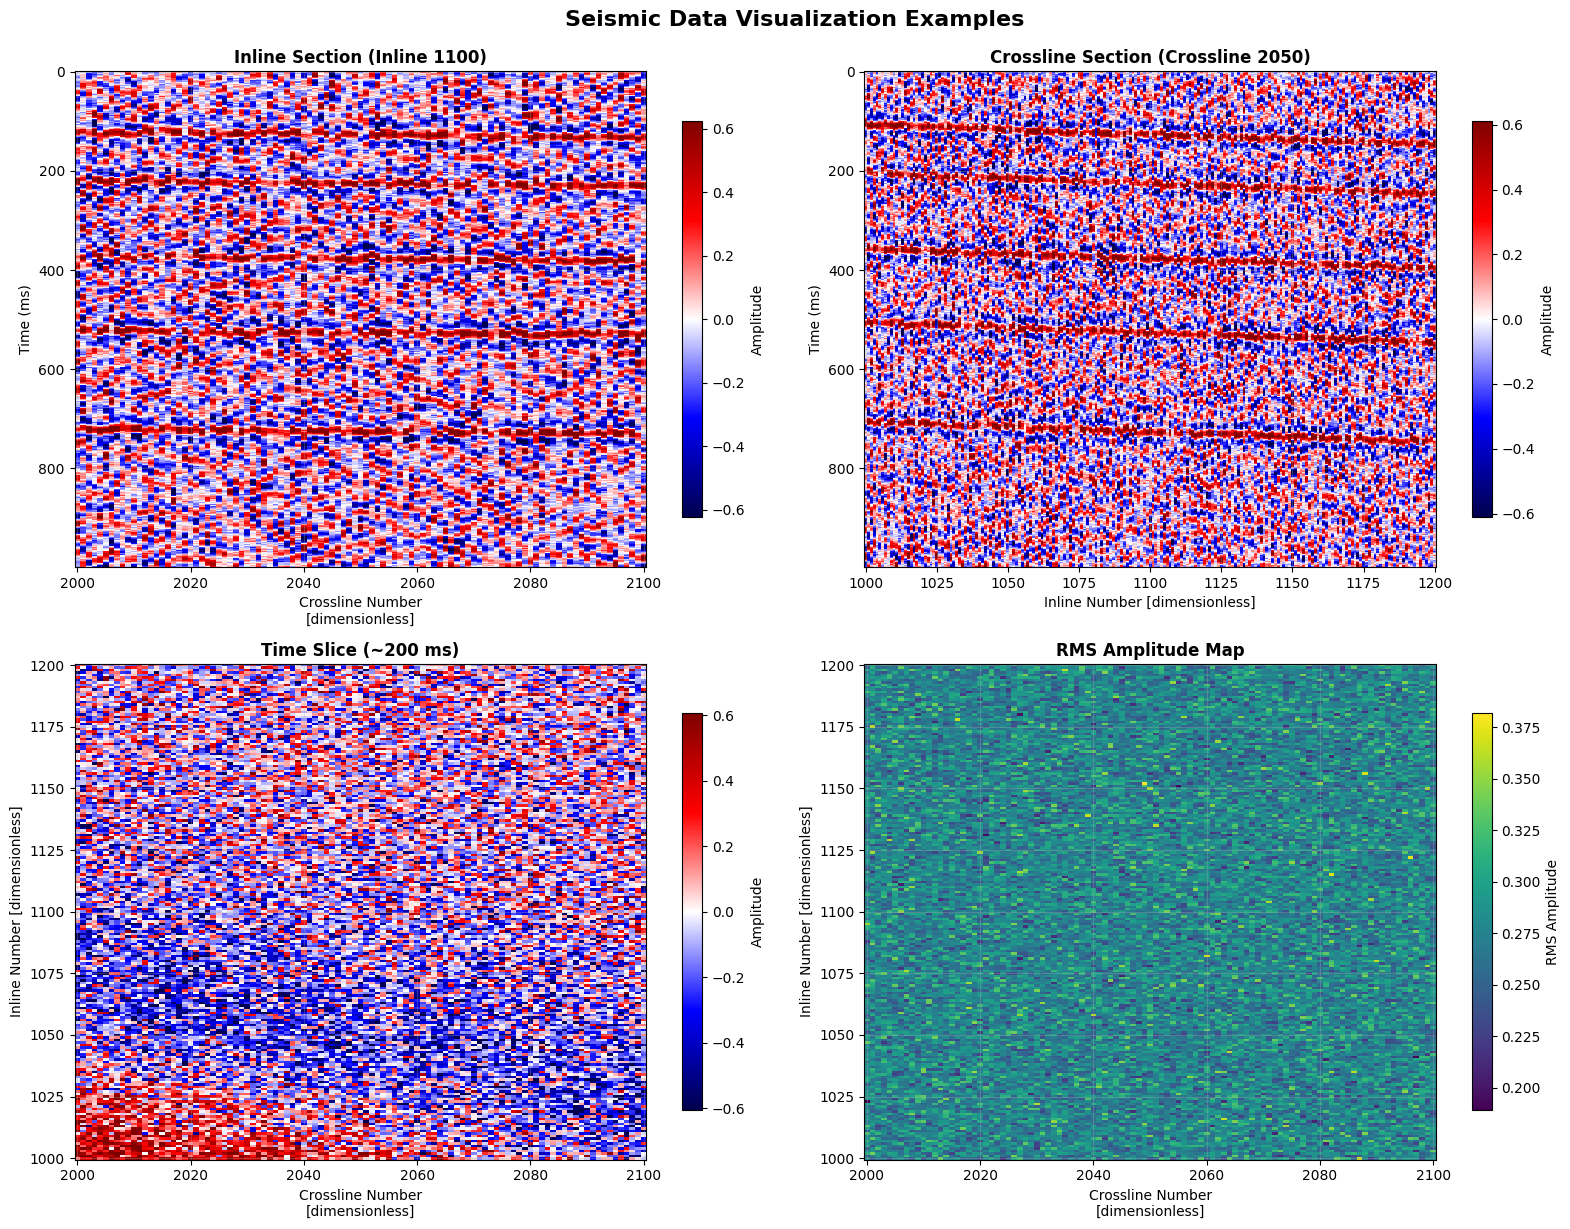

In [11]:
# Create a comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Inline section
inline_1100 = ds.sel(inline=1100)
im1 = inline_1100.Amplitude.plot(
    ax=axes[0,0], 
    x='crossline', 
    y='sample',
    cmap='seismic',
    robust=True,  # Better color scaling
    add_colorbar=False
)
axes[0,0].invert_yaxis()  # Time increases downward
axes[0,0].set_title('Inline Section (Inline 1100)', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Time (ms)')
axes[0,0].grid(True, alpha=0.3)

# 2. Crossline section
crossline_2050 = ds.sel(crossline=2050)
im2 = crossline_2050.Amplitude.plot(
    ax=axes[0,1],
    x='inline',
    y='sample',
    cmap='seismic',
    robust=True,
    add_colorbar=False
)
axes[0,1].invert_yaxis()
axes[0,1].set_title('Crossline Section (Crossline 2050)', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Time (ms)')
axes[0,1].grid(True, alpha=0.3)

# 3. Time slice
time_slice_200 = ds.sel(sample=200, method='nearest')
im3 = time_slice_200.Amplitude.plot(
    ax=axes[1,0],
    x='crossline',
    y='inline',
    cmap='seismic',
    robust=True,
    add_colorbar=False
)
axes[1,0].set_title(f'Time Slice (~{time_slice_200.sample.values:.0f} ms)', fontsize=12, fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

# 4. RMS amplitude map
rms_amplitude = np.sqrt((ds.Amplitude ** 2).mean('sample'))
im4 = rms_amplitude.plot(
    ax=axes[1,1],
    x='crossline',
    y='inline',
    cmap='viridis',
    add_colorbar=False
)
axes[1,1].set_title('RMS Amplitude Map', fontsize=12, fontweight='bold')
axes[1,1].grid(True, alpha=0.3)

# Add colorbars
plt.colorbar(im1, ax=axes[0,0], shrink=0.8, label='Amplitude')
plt.colorbar(im2, ax=axes[0,1], shrink=0.8, label='Amplitude')
plt.colorbar(im3, ax=axes[1,0], shrink=0.8, label='Amplitude')
plt.colorbar(im4, ax=axes[1,1], shrink=0.8, label='RMS Amplitude')

plt.tight_layout()
plt.suptitle('Seismic Data Visualization Examples', fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [ ]:
# Interactive trace display
def plot_trace_analysis(inline_num, crossline_num):
    """Plot detailed analysis of a single trace"""
    
    # Extract trace
    trace = ds.sel(inline=inline_num, crossline=crossline_num)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    
    # 1. Amplitude vs time
    trace.Amplitude.plot(ax=axes[0], y='sample')
    axes[0].invert_yaxis()
    axes[0].set_title(f'Trace: Inline {inline_num}, Crossline {crossline_num}')
    axes[0].set_xlabel('Amplitude')
    axes[0].grid(True, alpha=0.3)
    
    # 2. Frequency spectrum
    amplitude_values = trace.Amplitude.values
    sample_rate_hz = 1000.0 / (ds.sample.diff('sample').values[0])  # Convert ms to Hz
    frequencies, psd = signal.welch(amplitude_values, sample_rate_hz, nperseg=min(256, len(amplitude_values)//4))
    
    axes[1].semilogy(frequencies, psd)
    axes[1].set_xlabel('Frequency (Hz)')
    axes[1].set_ylabel('Power Spectral Density')
    axes[1].set_title('Frequency Spectrum')
    axes[1].grid(True, alpha=0.3)
    
    # 3. Instantaneous amplitude (envelope)
    analytic_signal = signal.hilbert(amplitude_values)
    envelope = np.abs(analytic_signal)
    
    axes[2].plot(amplitude_values, ds.sample.values, label='Original', alpha=0.7)
    axes[2].plot(envelope, ds.sample.values, label='Envelope', linewidth=2)
    axes[2].plot(-envelope, ds.sample.values, label='Envelope', linewidth=2)
    axes[2].invert_yaxis()
    axes[2].set_xlabel('Amplitude')
    axes[2].set_ylabel('Time (ms)')
    axes[2].set_title('Instantaneous Amplitude')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Example trace analysis
plot_trace_analysis(1100, 2050)

## 5. Performance Benefits

Let's demonstrate the performance advantages of chunked, lazy loading:

In [ ]:
import time

print("⚡ Performance Demonstration:")
print(f"Dataset size: {ds.nbytes / 1e6:.1f} MB\n")

# 1. Fast metadata operations
start_time = time.time()
subset = ds.sel(inline=slice(1050, 1150), crossline=slice(2025, 2075))
selection_time = time.time() - start_time
print(f"✅ Subset selection: {selection_time*1000:.1f} ms (no data loaded yet!)")

# 2. Lazy operations (no computation yet)
start_time = time.time()
mean_calculation = subset.Amplitude.mean()
lazy_time = time.time() - start_time
print(f"✅ Mean calculation setup: {lazy_time*1000:.1f} ms (still lazy!)")

# 3. Actual computation (now data is loaded and processed)
start_time = time.time()
result = mean_calculation.compute()
compute_time = time.time() - start_time
print(f"✅ Actual computation: {compute_time*1000:.1f} ms")
print(f"   Result: {result.values:.6f}")

print(f"\n💡 Total time: {(selection_time + lazy_time + compute_time)*1000:.1f} ms")
print(f"💡 Most time spent in actual computation, not data management!")

In [ ]:
# Demonstrate chunked parallel processing
print("🧩 Chunked Processing Benefits:")

if hasattr(ds.Amplitude.data, 'chunks'):
    print(f"✅ Data is chunked for parallel processing")
    print(f"   Chunk sizes: {ds.Amplitude.chunksizes}")
    print(f"   Total chunks: {ds.Amplitude.data.npartitions}")
    
    # Example: Parallel computation across chunks
    start_time = time.time()
    
    # This operation will be automatically parallelized across chunks
    rms_per_trace = np.sqrt((ds.Amplitude ** 2).mean('sample'))
    max_rms = rms_per_trace.max().compute()
    
    parallel_time = time.time() - start_time
    
    print(f"✅ RMS calculation across all traces: {parallel_time*1000:.1f} ms")
    print(f"   Maximum RMS value: {max_rms.values:.6f}")
    print(f"   Processing ~{ds.dims['inline'] * ds.dims['crossline']} traces")
    
else:
    print("ℹ️  Data is not chunked (using synthetic data)")
    print("   In real VDS files, data would be automatically chunked")

## 6. Data Analysis Workflows

Let's demonstrate some common seismic analysis workflows:

In [ ]:
# Workflow 1: Quality Control Analysis
print("🔍 Quality Control Analysis:")

# Check for data completeness
null_count = ds.Amplitude.isnull().sum().compute()
print(f"  Null values: {null_count.values}")

# Check amplitude range
amp_min = ds.Amplitude.min().compute()
amp_max = ds.Amplitude.max().compute()
print(f"  Amplitude range: {amp_min.values:.6f} to {amp_max.values:.6f}")

# Check for potential clipping
clip_threshold = 0.95
clipped_samples = (ds.Amplitude.abs() > clip_threshold).sum().compute()
total_samples = ds.Amplitude.size
clip_percentage = (clipped_samples / total_samples * 100).values
print(f"  Potential clipping (>{clip_threshold}): {clipped_samples.values} samples ({clip_percentage:.3f}%)")

# Signal-to-noise analysis
signal_window = ds.Amplitude.sel(sample=slice(100, 400))  # Signal window
noise_window = ds.Amplitude.sel(sample=slice(800, 900))   # Noise window (assuming quiet zone)

signal_rms = np.sqrt((signal_window ** 2).mean('sample'))
noise_rms = np.sqrt((noise_window ** 2).mean('sample'))
snr = (signal_rms / noise_rms).compute()

print(f"  Average S/N ratio: {snr.mean().values:.2f}")
print(f"  S/N ratio range: {snr.min().values:.2f} to {snr.max().values:.2f}")

In [ ]:
# Workflow 2: Structural Analysis
print("🏔️  Structural Analysis:")

# Calculate dip and azimuth (simplified)
def calculate_structural_attributes(data_slice):
    """Calculate basic structural attributes"""
    
    # Calculate gradients
    grad_inline = np.gradient(data_slice.values, axis=0)
    grad_crossline = np.gradient(data_slice.values, axis=1)
    
    # Calculate dip magnitude
    dip_magnitude = np.sqrt(grad_inline**2 + grad_crossline**2)
    
    # Calculate dip azimuth
    dip_azimuth = np.arctan2(grad_crossline, grad_inline) * 180 / np.pi
    
    return dip_magnitude, dip_azimuth

# Analyze structural attributes for a time slice
time_slice = ds.sel(sample=200, method='nearest')
dip_mag, dip_az = calculate_structural_attributes(time_slice.Amplitude)

print(f"  Time slice analyzed: {time_slice.sample.values:.0f} ms")
print(f"  Average dip magnitude: {np.mean(dip_mag):.6f}")
print(f"  Dip azimuth range: {np.min(dip_az):.1f}° to {np.max(dip_az):.1f}°")

# Visualize structural attributes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original amplitude
im1 = axes[0].imshow(time_slice.Amplitude.values, cmap='seismic', aspect='auto')
axes[0].set_title('Original Amplitude')
axes[0].set_xlabel('Crossline Index')
axes[0].set_ylabel('Inline Index')
plt.colorbar(im1, ax=axes[0])

# Dip magnitude
im2 = axes[1].imshow(dip_mag, cmap='viridis', aspect='auto')
axes[1].set_title('Dip Magnitude')
axes[1].set_xlabel('Crossline Index')
axes[1].set_ylabel('Inline Index')
plt.colorbar(im2, ax=axes[1])

# Dip azimuth
im3 = axes[2].imshow(dip_az, cmap='hsv', aspect='auto', vmin=-180, vmax=180)
axes[2].set_title('Dip Azimuth')
axes[2].set_xlabel('Crossline Index')
axes[2].set_ylabel('Inline Index')
plt.colorbar(im3, ax=axes[2], label='Degrees')

plt.tight_layout()
plt.show()

In [ ]:
# Workflow 3: Horizon Tracking
print("📈 Horizon Analysis:")

# Simple horizon picking based on maximum amplitude
def pick_horizon(amplitude_data, time_window):
    """Pick horizon based on maximum absolute amplitude in time window"""
    
    # Extract time window
    window_data = amplitude_data.sel(sample=slice(time_window[0], time_window[1]))
    
    # Find maximum amplitude in window
    max_indices = window_data.abs().argmax('sample')
    
    # Convert to actual time values
    horizon_times = window_data.sample.values[max_indices.values]
    
    return horizon_times

# Pick a horizon in the 150-250 ms window
horizon_times = pick_horizon(ds.Amplitude, (150, 250))

# Create horizon dataset
horizon_ds = xr.Dataset({
    'horizon_time': (['inline', 'crossline'], horizon_times)
}, coords={
    'inline': ds.inline,
    'crossline': ds.crossline
})

print(f"  Horizon picked in time window: 150-250 ms")
print(f"  Horizon time range: {np.min(horizon_times):.1f} to {np.max(horizon_times):.1f} ms")
print(f"  Average horizon time: {np.mean(horizon_times):.1f} ms")
print(f"  Horizon relief: {np.max(horizon_times) - np.min(horizon_times):.1f} ms")

# Visualize horizon
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Horizon map
im1 = horizon_ds.horizon_time.plot(
    ax=axes[0],
    x='crossline',
    y='inline',
    cmap='terrain',
    add_colorbar=False
)
axes[0].set_title('Picked Horizon (Time Map)')
plt.colorbar(im1, ax=axes[0], label='Time (ms)')

# Horizon on seismic section
inline_section = ds.sel(inline=1100)
horizon_inline = horizon_ds.sel(inline=1100)

inline_section.Amplitude.plot(
    ax=axes[1],
    x='crossline',
    y='sample',
    cmap='seismic',
    robust=True,
    add_colorbar=False
)

# Overlay horizon
axes[1].plot(ds.crossline.values, horizon_inline.horizon_time.values, 
            'red', linewidth=3, label='Picked Horizon')
axes[1].invert_yaxis()
axes[1].set_title('Horizon on Seismic Section (Inline 1100)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Export and Integration

Finally, let's see how to export results and integrate with other tools:

In [ ]:
# Export examples
print("💾 Export Examples:")

# 1. Export subset to NetCDF
subset = ds.sel(inline=slice(1050, 1150), crossline=slice(2025, 2075))
subset.to_netcdf('seismic_subset.nc')
print(f"  ✅ Subset exported to NetCDF: seismic_subset.nc")

# 2. Export horizon to CSV
horizon_df = horizon_ds.to_dataframe().reset_index()
horizon_df.to_csv('horizon_times.csv', index=False)
print(f"  ✅ Horizon exported to CSV: horizon_times.csv")

# 3. Export trace for detailed analysis
trace = ds.sel(inline=1100, crossline=2050)
trace_df = trace.to_dataframe().reset_index()
trace_df.to_csv('trace_analysis.csv', index=False)
print(f"  ✅ Single trace exported to CSV: trace_analysis.csv")

# 4. Export RMS map
rms_map = np.sqrt((ds.Amplitude ** 2).mean('sample'))
rms_map.to_netcdf('rms_amplitude_map.nc')
print(f"  ✅ RMS map exported to NetCDF: rms_amplitude_map.nc")

print(f"\n📊 Integration Examples:")

# Convert to numpy for custom analysis
amplitude_array = subset.Amplitude.values
print(f"  📐 Numpy array shape: {amplitude_array.shape}")

# Convert to pandas for statistical analysis
sample_df = ds.Amplitude.sel(sample=slice(0, 100)).to_dataframe()
print(f"  📋 Pandas DataFrame shape: {sample_df.shape}")
print(f"     Columns: {list(sample_df.columns)}")

# Prepare data for machine learning
# Example: Each trace becomes a feature vector
ml_features = ds.Amplitude.values.reshape(ds.dims['inline'] * ds.dims['crossline'], ds.dims['sample'])
print(f"  🤖 ML features shape: {ml_features.shape} (samples × features)")
print(f"     Ready for scikit-learn, tensorflow, etc.")

## Summary

This notebook demonstrated the key capabilities of the VDS Xarray Backend:

### 🎯 **Key Benefits Shown**:

1. **Simple Loading**: `xr.open_dataset('file.vds', engine='vds')` - that's it!

2. **Coordinate-Aware Operations**: Use real coordinates, not array indices
   ```python
   ds.sel(inline=1500, sample=200)  # Clear and intuitive
   ```

3. **Lazy Loading**: Work with datasets larger than memory
   - Instant loading (metadata only)
   - Data loaded only when needed
   - Automatic chunking for parallel processing

4. **Rich Visualization**: Built-in plotting with coordinate awareness
   ```python
   ds.Amplitude.sel(inline=1500).plot(x='crossline', y='sample')
   ```

5. **Seamless Integration**: Works with entire scientific Python ecosystem
   - matplotlib for visualization
   - scipy for signal processing
   - pandas for tabular analysis
   - scikit-learn for machine learning

6. **Performance**: Chunked, parallel processing with dask
   - Automatic parallelization
   - Memory-efficient operations
   - Scales to any dataset size

### 🚀 **Next Steps**:

- Try with your own VDS files
- Explore advanced workflows in the [User Guide](../docs/USER-GUIDE.md)
- Read about the technical details in [Technical Overview](../docs/TECHNICAL-OVERVIEW.md)
- Understand the motivation in [Why Xarray?](../docs/WHY-XARRAY.md)

### 💡 **Remember**:

The VDS Xarray Backend makes seismic data analysis:
- **More intuitive** (coordinate-aware operations)
- **More efficient** (lazy loading, chunked processing)
- **More powerful** (rich ecosystem integration)
- **More reliable** (metadata preservation, error handling)

Happy analyzing! 🎉